In [2]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import sys
np.set_printoptions(threshold=sys.maxsize)

In [3]:
# IMPORT DATA

hub = np.loadtxt("data.dat", skiprows=6)

dist = hub[:,0]
distErr = hub[:,1]
vel = hub[:,2]

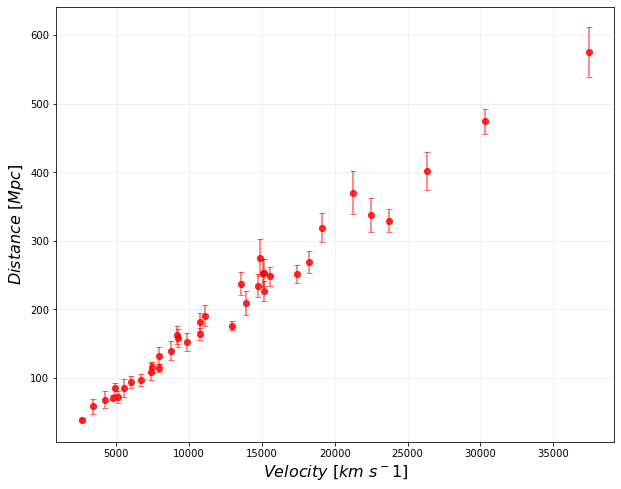

In [4]:
# REARRANGE DATA, ERRORS ON THE Y AXIS

plt.figure(figsize=(10,8))

plt.scatter(vel, dist, color='r', alpha=0.5)
plt.errorbar(vel, dist, yerr=distErr, fmt="o", capsize=3, c='r', alpha=0.6)
plt.grid(alpha=0.25)

plt.ylabel('$Distance$ $[Mpc]$',fontsize=16)
plt.xlabel('$Velocity$ $[km$ $s^-1]$',fontsize=16)

plt.savefig("RawData.png", dpi=300)

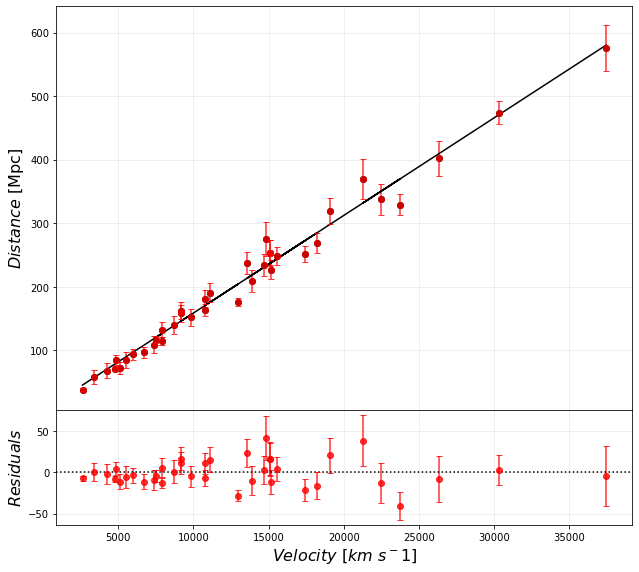

In [5]:
# UNWEIGHTED 1D LINEAR REGRESSION & RESIDUALS

plt.figure(figsize=(10,8))

# FIRST FRAME DRAWS THE PREVIOUS DATA AND A 1D LINEAR REGRESSION
fig1 = plt.figure(1)
frame1=fig1.add_axes((.1,.3,.8,.7))

coef = np.polyfit(vel, dist, 1)
poly1d_fn = np.poly1d(coef) 
plt.plot(vel, dist, 'o', vel, poly1d_fn(vel), color='k')
plt.errorbar(vel, dist, yerr=distErr, fmt="o", capsize=3, alpha=0.8, c='r')

plt.ylabel('$Distance$ [Mpc]',fontsize=16)
plt.autoscale(enable=True, axis=u'both', tight=False)
plt.grid(True, alpha=0.25)

# SECOND FRAME DRAWS THE RESIDUALS FROM THE PROJECTED LINEAR REGRESSION
frame2=fig1.add_axes((.1,.1,.8,.20))

res = dist - poly1d_fn(vel) # CALLS THE FUNCTION OF THE LINEAR REGR
plt.axhline(y=0, color='k', linestyle=':') # DRAWS A HORIZONTAL DASHED LINE WHEN RESIDUALS ARE ZERO
plt.errorbar(vel, res, yerr=distErr, fmt="o", capsize=3, alpha=0.8, c='r')

frame2.set_ylabel('$Residuals$',fontsize=16)
plt.xlabel('$Velocity$ $[km$ $s^-1]$',fontsize=16)
plt.grid(True, alpha=0.25)

plt.savefig("PolyFit.png", dpi=300)

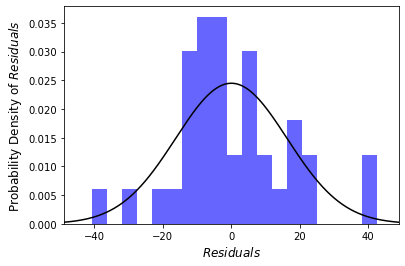

In [6]:
# HISTOGRAM OF THE RESIDUALS

mean = np.mean(res)
sd = np.std(res)

# SETS THE BOUNDS OF THE PLOT
left = mean - 3*sd
right = mean + 3*sd
x_axis = np.arange(left, right, 0.01)

# DRAWS A NORMAL DISTRIBUTION ON THESE BOUNDS
plt.plot(x_axis, norm.pdf(x_axis, mean, sd), color='k') 

# DRAWS THE PROBABILITY DENSITY DISTRIBUTION FOR THE RESIDUALS
plt.hist(res, bins=19, density=True, alpha=0.6, color='b') 
plt.ylabel('Probability Density of $Residuals$', fontsize=12)
plt.xlabel('$Residuals$', fontsize=12)
plt.xlim(left, right)

plt.savefig("ResHist.png", dpi=300)

In [7]:
# UNWEIGHTED NORMAL EQUATION NUMERICAL SOLN
# x = vel
# y = dist

# DESIGN MATRIX X CONCATENATION
dista = np.resize(dist, (38,1))
ones = np.resize(np.ones(len(dist)), (38,1))
X = np.concatenate((ones, dista), axis = 1)

# UNWEIGHTED NORMAL EQUATION
XT = np.matrix.transpose(X)
XTX = np.dot(XT, X)
XTXinv = np.linalg.inv(XTX)
XTY = np.dot(XT, vel)
beta = np.linalg.solve(XTX,XTY)

# THE BETA OUTPUT IS NEARLY SIMILAR TO THE OUTPUT OF THE UNWEIGHTED POLYFIT
coefFlip = np.polyfit(dist, vel, 1) # FLIPPED THE AXES TO MATCH THE UNWEIGHTED NORMAL EQUATION FORM
beta[0], coefFlip[1], beta[1], coefFlip[0]

(-90.02369672519092, -90.02369672519252, 63.92534733310883, 63.92534733310884)

In [8]:
# WEIGHTED POLYFIT REGRESSION TO CALCULATE THE COVARIANCE MATRIX

weights = 1.0/distErr**1 # polyfit peculiarity

theta = np.polyfit(vel, dist, 1, w=weights, cov='unscaled')
thetabest = theta[0]
thetacov = theta[1]

# PRINTS THE CORRESPONDING COEFFICIENT AND ITS ERROR
for i in range(len(theta[0])):
    print('a[',i,'] = ',thetabest[len(theta[0])-i-1],'+/-',np.sqrt(thetacov[len(theta[0])-i-1][len(theta[0])-i-1]))

print() 
print('Covariance matrix = ')
print(thetacov)

theta

a[ 0 ] =  -0.6427312185483397 +/- 2.4602089528651327
a[ 1 ] =  0.01530758885877077 +/- 0.00028718155241506894

Covariance matrix = 
[[ 8.24732440e-08 -5.68759808e-04]
 [-5.68759808e-04  6.05262809e+00]]


(array([ 0.01530759, -0.64273122]),
 array([[ 8.24732440e-08, -5.68759808e-04],
        [-5.68759808e-04,  6.05262809e+00]]))

In [9]:
# DIAGONAL OF THE COVARIANCE MATRIX AND ASSOCIATED ERROR

diag = np.diagonal(thetacov)
diag

array([8.24732440e-08, 6.05262809e+00])

In [10]:
# EXPRESS THE AGE OF THE UNIVERSE

Gyr = thetabest[0] * 3.086e+19 / (60*60*24*365*1000000000) # billion years
Err = np.sqrt(thetacov[0][0]) * 3.086e+19 / (60*60*24*365*1000000000) # billion years

print("The age of the Universe is: ", round(Gyr, 2), r'+/-', round(Err, 2), '[Gyr]')

The age of the Universe is:  14.98 +/- 0.28 [Gyr]


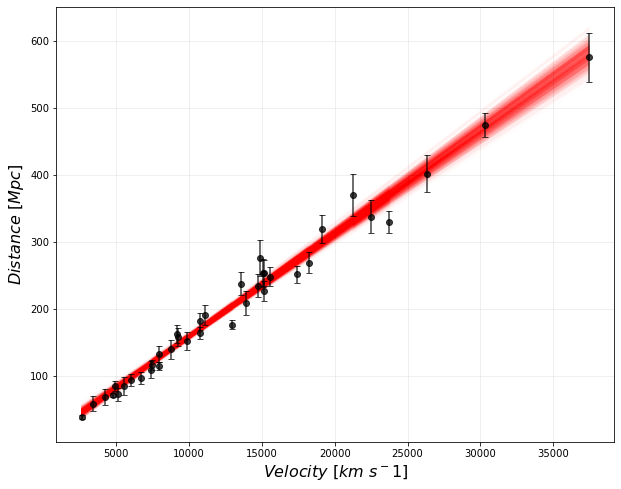

In [11]:
# BOOTSTRAP & PERTURBED PLOTS

plt.figure(figsize=(10,8))
MastLoop = np.empty(shape=[0, len(dist)]) # CREATES AN EMPTY ARRAY FOR N SIZE DATASETS

# CREATES 1000 PERTURBED DATASETS IN DISTANCE MEASUREMENT AND CONCATENATES INTO SINGLE LARGE MATRIX
for i in range(1000): 
    Pert = []
    for j in range(len(distErr)):
        inter = np.random.normal(dist[j], distErr[j])
        Pert = np.append(Pert, inter)
    MastLoop = np.append(MastLoop, [Pert], axis=0)

rngML = range(len(MastLoop))
rngPert = range(len(MastLoop[2]))
MLMat = np.empty(shape=[0,2])

# CREATES POLYFITS OF EACH PERTURBED DATASET AND CONCATENATES INTO SINGLE MATRIX
for k in rngML:
    coefPert = np.polyfit(vel, MastLoop[k], 1)
    CFunc = np.poly1d(coefPert)
    MLMat = np.append(MLMat, [CFunc], axis=0)
    
# DRAWS ALL PLOTS
for m in range(len(MLMat)):
    plt.plot(vel, np.poly1d(MLMat[m])(vel), c='r', alpha=0.01)
    
plt.errorbar(vel, dist, yerr=distErr, fmt="o", zorder=10, c='k', capsize = 3, alpha=0.75)
plt.grid(alpha=0.25)
plt.ylabel('$Distance$ $[Mpc]$',fontsize=16)
plt.xlabel('$Velocity$ $[km$ $s^-1]$',fontsize=16)

plt.savefig("Bootstrap.png", dpi=300)

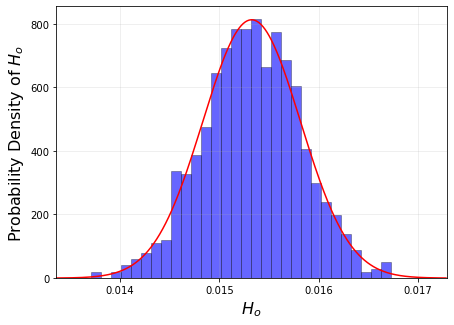

In [12]:
# HISTOGRAM OF Ho FROM BOOTSTRAP

Ho = MLMat[:,0]
mean = np.mean(Ho)
sd = np.std(Ho)

# SETS THE BOUNDS OF THE PLOT
left = mean - 4*sd
right = mean + 4*sd
x_Ho = np.arange(left, right, 0.00001)

plt.figure(figsize=(7,5))

# DRAWS A NORMAL DISTRIBUTION ON THESE BOUNDS
plt.plot(x_Ho, norm.pdf(x_Ho, mean, sd), color='r')

# DRAWS THE PROBABILITY DENSITY DISTRIBUTION FOR Ho
plt.hist(Ho, bins=30, alpha=0.6, color='b', edgecolor='k', linewidth=.5, density=True)
plt.ylabel('Probability Density of $H_o$', fontsize=16)
plt.xlabel('$H_o$', fontsize=16)
plt.grid(alpha=0.25)
plt.xlim(left, right)
plt.locator_params(axis='both', nbins=6)

plt.savefig("HoHist.png", dpi=300)

(-16.043413761966402, 27.10690216375573)

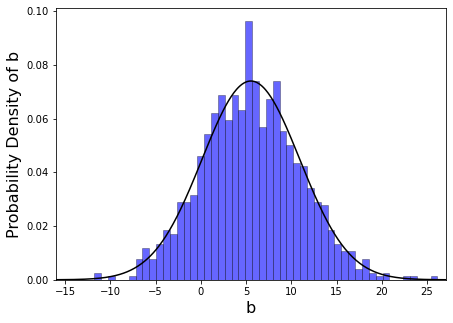

In [13]:
#BOOTSTRAP HISTOGRAM

b = MLMat[:,1]
mean = np.mean(b)
sd = np.std(b)

# SETS THE BOUNDS OF THE PLOT
left = mean - 4*sd
right = mean + 4*sd
x_b = np.arange(left, right, 0.1)

plt.figure(figsize=(7,5))

# DRAWS A NORMAL DISTRIBUTION ON THESE BOUNDS
plt.plot(x_b, norm.pdf(x_b, mean, sd), color='k')

# DRAWS THE PROBABILITY DENSITY DISTRIBUTION FOR Ho
plt.hist(b, bins=50, density=True, alpha=0.6, color='b', edgecolor='k', linewidth=.5)
plt.ylabel('Probability Density of b', fontsize=16)
plt.xlabel('b', fontsize=16)
plt.xlim(left, right)

(0.0, 38.0)

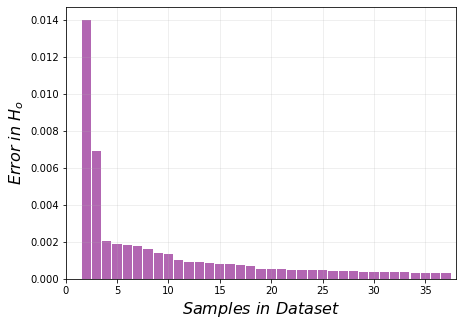

In [14]:
#CENSORED DATA UNCERTAINTY

Ctheta = []
Cthetabest = np.empty(shape=[0, 2])
Cthetacov = np.empty(shape=[0, 2])

# THIS CALCULATION ASSUMES STARTING WITH AT LEAST 2 DATAPOINTS
for i in range(len(dist)-2):
    Cdist = hub[:,0][:i+2]
    CdistErr = hub[:,1][:i+2]
    Cvel = hub[:,2][:i+2]
    Cweights = 1.0/CdistErr**1 # polyfit peculiarity
    Ctheta = np.polyfit(Cvel, Cdist, 1, w=Cweights, cov='unscaled')
    Cthetabest = np.append(Cthetabest, [Ctheta[0]], axis=0)
    Cthetacov = np.append(Cthetacov, [np.diag(Ctheta[1])], axis=0)

# CREATES A BAR PLOT OF THE ERROR IN TERMS OF SAMPLES IN THE COVERIANCE MATRIX
plt.figure(figsize=(7,5))
plt.bar(np.arange(2, 2+len(Cthetacov[:,0]), 1) , np.sqrt(Cthetacov[:,0]) , color ='purple', width = .9, alpha=0.6)
plt.ylabel('$Error$ $in$ $H_o$', size=16)
plt.xlabel('$Samples$ $in$ $Dataset$', fontsize=16)
plt.grid(alpha=0.25)
plt.xlim(0, 38)

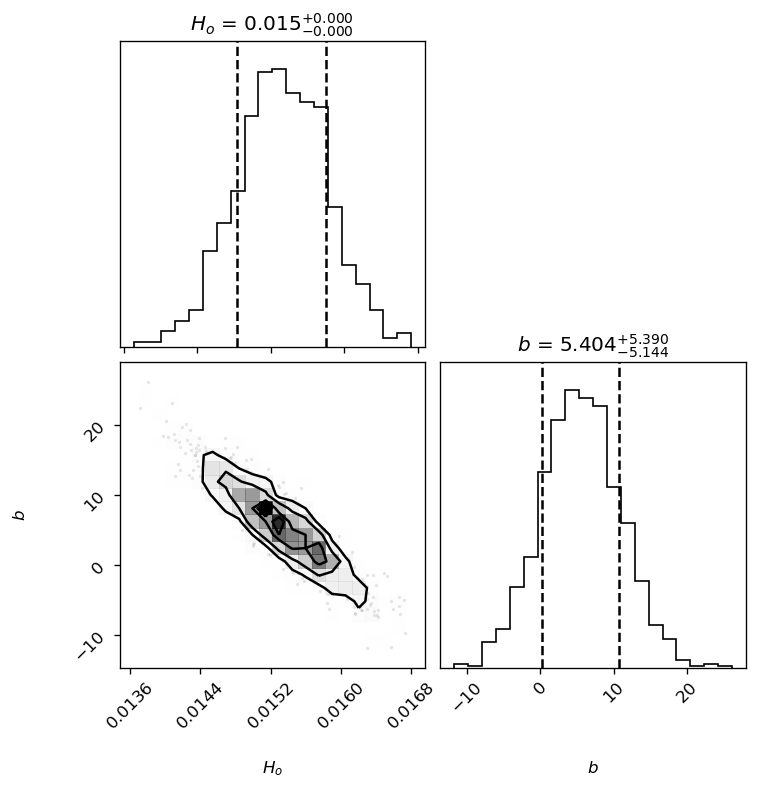

In [17]:
# CORNER PLOT OF THE Ho AND b FROM BOOTSTRAP CORRELATION

# RESHAPES DATA INTO MULTIDIM ARRAY
Ho = MLMat[:,0].reshape([len(MLMat),1])
b = MLMat[:,1].reshape([len(MLMat),1])
samples = np.concatenate((Ho,b),axis=1)

fig=plt.figure(figsize=(7,7),dpi=120)
fig=corner.corner(
    samples, labels=[r"$H_o$",r"$b$"],quantiles=(0.16, 0.84),show_titles=True,
    title_fmt = '.3f', use_math_text=True, fig=fig)

plt.savefig("CornerPlots.png", dpi=300)